PDF guardado: Initial-Copula.pdf


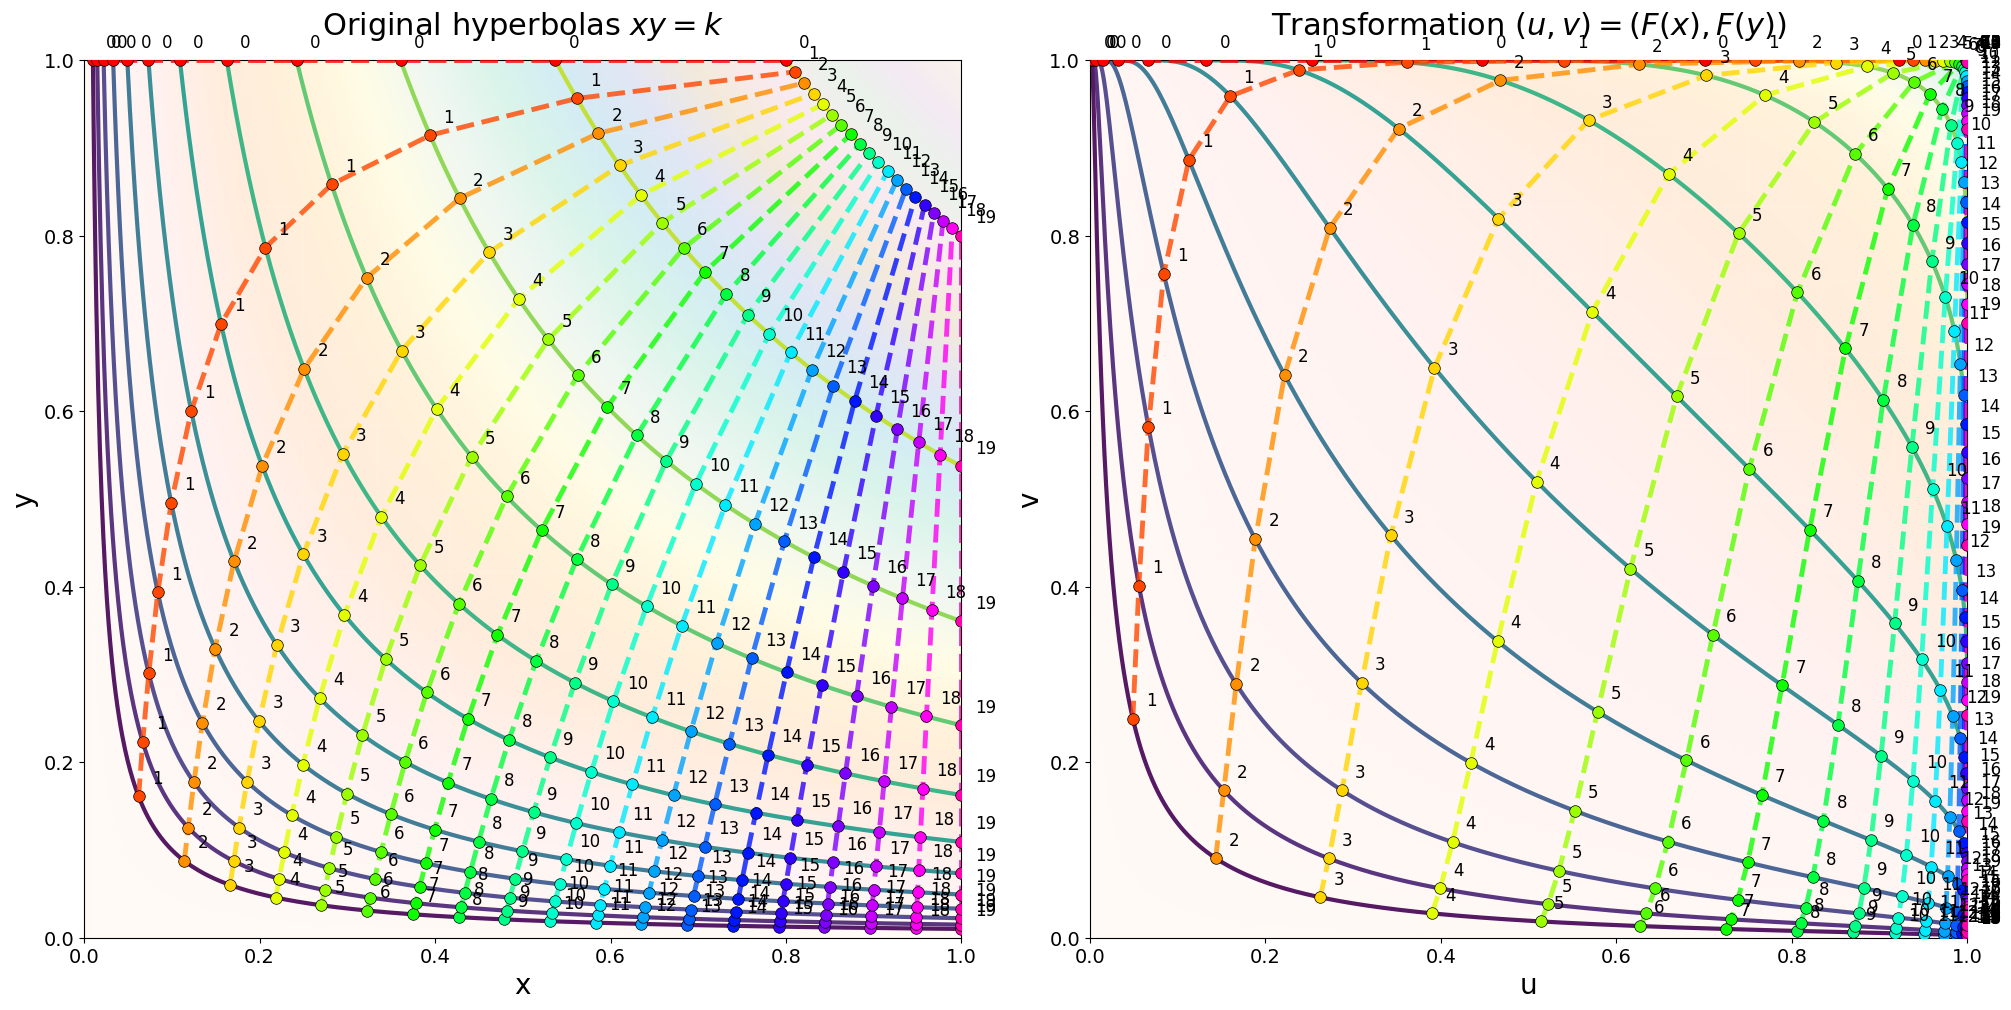

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from matplotlib.colors import LinearSegmentedColormap

# ==========================================================
# CONFIGURACIÓN GLOBAL DE FUENTES (TAMAÑO AUMENTADO)
# ==========================================================
plt.rcParams.update({
    'font.size': 16,          # Tamaño base
    'axes.labelsize': 18,     # Tamaño de etiquetas de ejes
    'axes.titlesize': 20,     # Tamaño de títulos
    'xtick.labelsize': 14,    # Tamaño de números en eje X
    'ytick.labelsize': 14,    # Tamaño de números en eje Y
    'legend.fontsize': 14,
    'figure.titlesize': 22
})

# ==========================================================
# PARÁMETROS
# ==========================================================
k_values = np.geomspace(0.01, 0.8, 12)
a = 2
b = 5

line_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
num_points_per_curve = 20
point_index_colors = plt.cm.hsv(np.linspace(0, 0.9, num_points_per_curve))

# ==========================================================
# ALMACENAMIENTO DE LA MALLA
# ==========================================================
mesh_x = [[] for _ in range(num_points_per_curve)]
mesh_y = [[] for _ in range(num_points_per_curve)]
mesh_u = [[] for _ in range(num_points_per_curve)]
mesh_v = [[] for _ in range(num_points_per_curve)]

# ==========================================================
# FUNCIÓN PARA SOMBREADO PRECISO (HEATMAP)
# ==========================================================
def create_precise_shading(ax, is_transformed=False, alpha=0.6):
    resolution = 300

    if is_transformed:
        u_grid = np.linspace(0.001, 0.999, resolution)
        v_grid = np.linspace(0.001, 0.999, resolution)
        U, V = np.meshgrid(u_grid, v_grid)
        X = beta.ppf(U, a, b)
        Y = beta.ppf(V, a, b)
        K = X * Y
    else:
        x_grid = np.linspace(0.001, 0.999, resolution)
        y_grid = np.linspace(0.001, 0.999, resolution)
        X, Y = np.meshgrid(x_grid, y_grid)
        K = X * Y

    pastel_colors = [
        '#FFF5EE', '#FFE4E1', '#FFDAB9', '#FFE4B5', '#FFFACD',
        '#E0F0E3', '#B5EAD7', '#A8D8EA', '#C7CEEA', '#E8D5B7',
        '#F5D5E0', '#D5E8D5', '#E8D5E8', '#F5E6D5'
    ]
    pastel_cmap = LinearSegmentedColormap.from_list(
        'pastel_gradient',
        pastel_colors,
        N=256
    )

    im = ax.imshow(
        K,
        extent=[0, 1, 0, 1],
        origin='lower',
        cmap=pastel_cmap,
        aspect='auto',
        vmin=0.001,
        vmax=1.0,
        zorder=0,
        alpha=alpha,
        interpolation='bilinear'
    )
    return im

# ==========================================================
# FIGURA
# ==========================================================
fig, ax = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

# ==========================================================
# SOMBREADO
# ==========================================================
im1 = create_precise_shading(ax[0], is_transformed=False, alpha=0.5)
im2 = create_precise_shading(ax[1], is_transformed=True, alpha=0.5)

# ==========================================================
# DIBUJAR CURVAS Y RECOLECTAR PUNTOS
# ==========================================================
for i, k in enumerate(k_values):
    line_color = line_colors[i]
    x = np.linspace(k, 1.0, num_points_per_curve)
    y = k / x

    u = beta.cdf(x, a, b)
    v = beta.cdf(y, a, b)

    for j in range(num_points_per_curve):
        mesh_x[j].append(x[j])
        mesh_y[j].append(y[j])
        mesh_u[j].append(u[j])
        mesh_v[j].append(v[j])

    xx = np.linspace(k, 1.0, 1000)
    yy = k / xx
    uu = beta.cdf(xx, a, b)
    vv = beta.cdf(yy, a, b)

    # Espacio original
    ax[0].plot(xx, yy, color=line_color, lw=3, alpha=0.9, zorder=2)
    for j in range(num_points_per_curve):
        ax[0].scatter(x[j], y[j], color=point_index_colors[j],
                      s=70, edgecolors='black', linewidth=0.5, zorder=5)
        # Tamaño de letra de los números aumentado a 12
        ax[0].text(x[j] + 0.015, y[j] + 0.015, str(j),
                   fontsize=12, zorder=6)

    # Espacio transformado
    ax[1].plot(uu, vv, color=line_color, lw=3, alpha=0.9, zorder=2)
    for j in range(num_points_per_curve):
        ax[1].scatter(u[j], v[j], color=point_index_colors[j],
                      s=70, edgecolors='black', linewidth=0.5, zorder=5)
        ax[1].text(u[j] + 0.015, v[j] + 0.015, str(j),
                   fontsize=12, zorder=6)

# ==========================================================
# SEGUNDA FAMILIA DE CURVAS (MALLA)
# ==========================================================
for j in range(num_points_per_curve):
    color_j = point_index_colors[j]
    ax[0].plot(mesh_x[j], mesh_y[j], '--', color=color_j,
               lw=3.5, alpha=0.8, zorder=3)
    ax[1].plot(mesh_u[j], mesh_v[j], '--', color=color_j,
               lw=3.5, alpha=0.8, zorder=3)

# ==========================================================
# LÍNEAS DE CUADRÍCULA
# ==========================================================
for i in range(13):
    pos = i / 12
    ax[0].axvline(x=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)
    ax[0].axhline(y=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)
    ax[1].axvline(x=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)
    ax[1].axhline(y=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)

# ==========================================================
# FORMATO DE LOS PANELES (TÍTULOS Y ETIQUETAS CON TAMAÑO GRANDE)
# ==========================================================
ax[0].set_title(r'Original hyperbolas $xy=k$', fontsize=22, y=1.02)
ax[0].set_xlabel('x', fontsize=20)
ax[0].set_ylabel('y', fontsize=20)
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].set_aspect('equal')
ax[0].grid(False)

ax[1].set_title(r'Transformation $(u,v)=(F(x),F(y))$', fontsize=22, y=1.02)
ax[1].set_xlabel('u', fontsize=20)
ax[1].set_ylabel('v', fontsize=20)
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)
ax[1].set_aspect('equal')   # ← corregido
ax[1].grid(False)

# ==========================================================
# GUARDAR PDF CON EL NOMBRE QUE USA EL LaTeX
# ==========================================================
pdf_name = "Initial-Copula.pdf"
plt.savefig(pdf_name, format='pdf', dpi=300, bbox_inches='tight')
print(f"PDF guardado: {pdf_name}")

plt.show()